# Smoking

In [3]:
library(tidysynth)
require(tidysynth)
data(smoking)

Warning message:
"pacote 'tidysynth' foi compilado no R versão 4.4.3"


In [4]:
smoking

state,year,cigsale,lnincome,beer,age15to24,retprice
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Rhode Island,1970,123.9,NA,NA,0.1831579,39.3
Tennessee,1970,99.8,NA,NA,0.1780438,39.9
Indiana,1970,134.6,NA,NA,0.1765159,30.6
Nevada,1970,189.5,NA,NA,0.1615542,38.9
Louisiana,1970,115.9,NA,NA,0.1851852,34.3
Oklahoma,1970,108.4,NA,NA,0.1754592,38.4
New Hampshire,1970,265.7,NA,NA,0.1707317,31.4
North Dakota,1970,93.8,NA,NA,0.1844660,37.3
Arkansas,1970,100.3,NA,NA,0.1690068,36.7


In [5]:

smoking_out <-

  smoking %>%
  synthetic_control(outcome = cigsale, 
                    unit = state,
                    time = year,
                    i_unit = "California",
                    i_time = 1988,
                    generate_placebos=T)


In [6]:

smoking_out <- smoking_out %>%
generate_predictor(time_window = 1980:1988,
ln_income = mean(lnincome, na.rm = T),
ret_price = mean(retprice, na.rm = T),
youth = mean(age15to24, na.rm = T))


In [7]:

smoking_out <- smoking_out %>%
  generate_predictor(
    time_window = 1984:1988,
    beer_sales = mean(beer, na.rm = TRUE)
  )


In [8]:

smoking_out <- smoking_out %>%
  generate_predictor(
    time_window = 1975,
    cigsale_1975 = cigsale
  ) %>%
  generate_predictor(
    time_window = 1980,
    cigsale_1980 = cigsale
  ) %>%
  generate_predictor(
    time_window = 1988,
    cigsale_1988 = cigsale
  )


In [9]:

smoking_out <- smoking_out %>%
  generate_predictor(
    time_window = 1975,
    cigsale_1975 = cigsale
  ) %>%
  generate_predictor(
    time_window = 1980,
    cigsale_1980 = cigsale
  ) %>%
  generate_predictor(
    time_window = 1988,
    cigsale_1988 = cigsale
  )


In [10]:

smoking_out <- smoking_out %>%
  generate_weights(
    optimization_window = 1970:1988,
    margin_ipop = 0.02,
    sigf_ipop = 7,
    bound_ipop = 6
  )


In [11]:

smoking_out <- smoking_out %>%
generate_control()


Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the tidysynth package.
  Please report the issue to the authors."


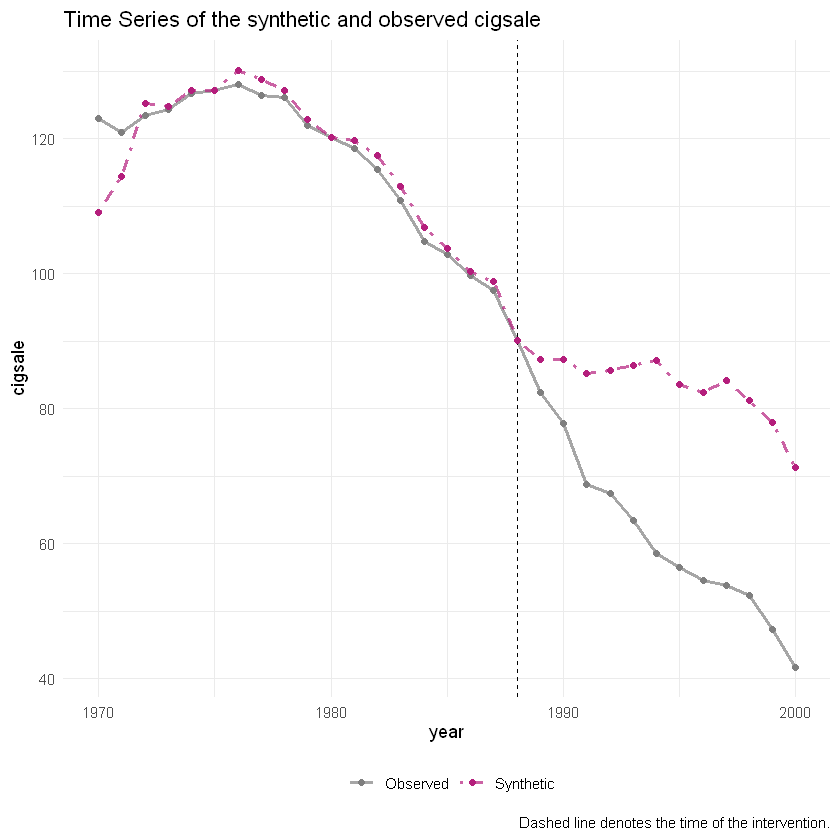

In [12]:

smoking_out %>% plot_trends()


Ignoring unknown labels:
• colour : ""
• linetype : ""


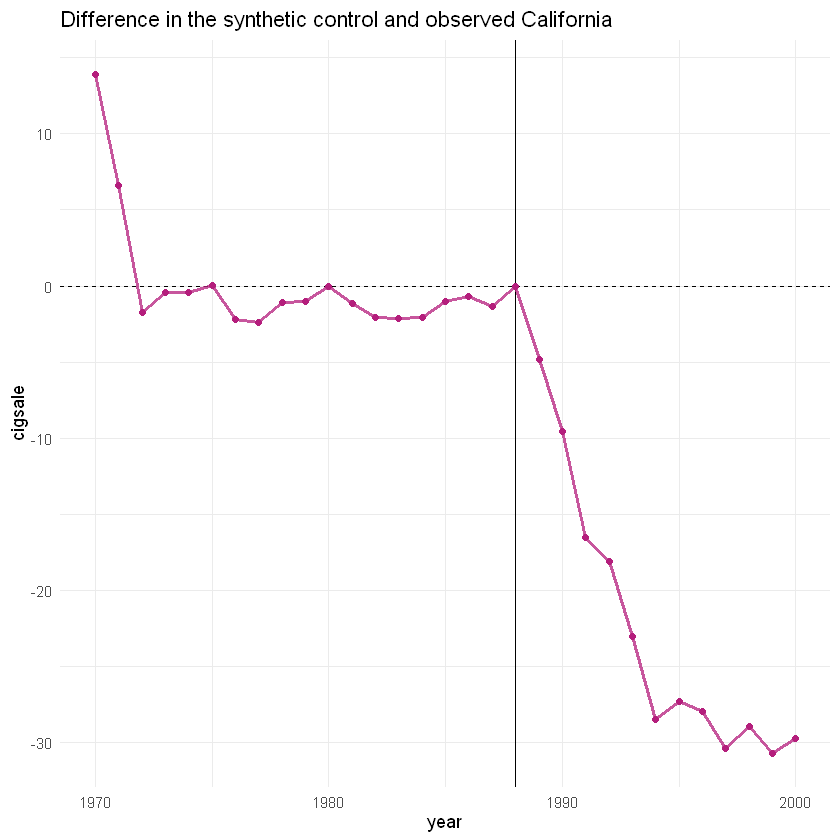

In [13]:

smoking_out %>% plot_differences()


In [14]:

smoking_out %>% grab_balance_table()


variable,California,synthetic_California,donor_sample
<chr>,<dbl>,<dbl>,<dbl>
cigsale_1975,127.1,127.09534,136.9316
cigsale_1980,120.2,120.19964,138.0895
cigsale_1988,90.1,90.10015,113.8237
